# 03. DAY 2 모델 개발 및 평가

## 평가 원칙

- **Train:** Batch 1 정책 단위 Group CV
- **Valid:** Batch 1 정책 단위 Hold-out
- **Test:** Batch 2 최종 1회 평가
- **Target:** `cycle_life` 회귀
- **주요 지표:** MAPE
- **원논문 Target:** 9.1%

Batch 2는 피처, 모델, 하이퍼파라미터를 모두 고정한 뒤 마지막에 한 번만 평가합니다.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURE_DIR = RESULTS_DIR / 'figures' / 'day2'
MODEL_DIR = RESULTS_DIR / 'models'
for directory in [RESULTS_DIR, FIGURE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

batch1 = pd.read_parquet(PROCESSED_DIR / 'batch1_features.parquet')
batch2_all = pd.read_parquet(PROCESSED_DIR / 'batch2_features.parquet')

FEATURES = ['dQ_log_var', 'QD_slope', 'chargetime_10', 'c_rate_1']
TARGET = 'cycle_life'
GROUP = 'charging_policy'
PAPER_TARGET_MAPE = 9.1
RANDOM_STATE = 42
ALPHAS = np.logspace(-3, 3, 13)

# cycle_life가 없는 VarCharge/SlowCycle 8개 셀은 입력 피처는 있지만
# 오차를 계산할 수 없으므로 Batch 2 성능 평가에서 제외한다.
batch2 = batch2_all.dropna(subset=FEATURES + [TARGET]).copy()

print('Batch 1:', batch1.shape, '| policies:', batch1[GROUP].nunique())
print('Batch 2 raw:', batch2_all.shape, '| labeled evaluation cells:', batch2.shape)
print('Batch 2 evaluation policies:', batch2[GROUP].nunique())
display(batch1[FEATURES + [TARGET]].describe().T)
display(batch2[FEATURES + [TARGET]].describe().T)

Batch 1: (46, 54) | policies: 23
Batch 2 raw: (47, 54) | labeled evaluation cells: (39, 54)
Batch 2 evaluation policies: 12


,count,mean,std,min,25%,50%,75%,max
dQ_log_var,46.0,-3.922996,0.378273,-5.014427,-4.052977,-3.850725,-3.667775,-3.349904
QD_slope,46.0,-0.000013,0.000031,-0.000161,-0.000019,-0.000010,0.000006,0.000023
chargetime_10,46.0,11.029807,1.005811,8.981218,10.203807,11.001237,11.586331,13.426407
c_rate_1,46.0,5.878261,1.202574,3.600000,5.400000,6.000000,6.750000,8.000000
cycle_life,46.0,844.717391,184.629198,534.000000,703.250000,858.500000,914.250000,1227.000000


,count,mean,std,min,25%,50%,75%,max
dQ_log_var,39.0,-3.595842,0.394189,-4.448151,-3.673659,-3.486830,-3.335129,-3.085447
QD_slope,39.0,0.000003,0.000071,-0.000252,-0.000037,0.000003,0.000062,0.000116
chargetime_10,39.0,10.149996,0.064594,10.036118,10.168913,10.173625,10.176544,10.256875
c_rate_1,39.0,5.030769,0.614155,3.600000,4.800000,5.200000,5.600000,6.000000
cycle_life,39.0,565.743590,222.201629,392.000000,439.500000,472.000000,508.500000,1186.000000


## 1. Batch 1 정책 단위 Train·Valid 분리

동일 충전 정책의 셀이 양쪽에 나뉘지 않도록 `charging_policy`를 그룹으로 사용합니다.

In [2]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, valid_idx = next(splitter.split(batch1, batch1[TARGET], groups=batch1[GROUP]))
train_df = batch1.iloc[train_idx].copy()
valid_df = batch1.iloc[valid_idx].copy()

assert set(train_df[GROUP]).isdisjoint(set(valid_df[GROUP]))
split_summary = pd.DataFrame({
    'split': ['Train', 'Valid'],
    'cells': [len(train_df), len(valid_df)],
    'policies': [train_df[GROUP].nunique(), valid_df[GROUP].nunique()],
    'life_min': [train_df[TARGET].min(), valid_df[TARGET].min()],
    'life_median': [train_df[TARGET].median(), valid_df[TARGET].median()],
    'life_max': [train_df[TARGET].max(), valid_df[TARGET].max()],
})
display(split_summary)

,split,cells,policies,life_min,life_median,life_max
0,Train,35,18,534.0,857.0,1227.0
1,Valid,11,5,691.0,860.0,1190.0


## 2. 모델과 평가 함수

- Linear Regression은 Ridge 개선 여부를 판단하는 기준선입니다.
- Ridge는 DAY 1에서 정한 우선 모델입니다.
- 결측치 처리와 표준화는 각 fold의 Train에서만 학습합니다.
- Ridge CV 성능은 바깥 GroupKFold와 안쪽 GridSearch를 사용한 중첩 검증으로 계산합니다.

In [3]:
def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model),
    ])


def regression_metrics(y_true, y_pred):
    return {
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }


def group_cv_predictions(estimator, frame, n_splits=5):
    X = frame[FEATURES]
    y = frame[TARGET]
    groups = frame[GROUP]
    cv = GroupKFold(n_splits=n_splits)
    pred = np.full(len(frame), np.nan)
    fold_rows = []
    for fold, (fit_idx, val_idx) in enumerate(cv.split(X, y, groups), start=1):
        fitted = clone(estimator).fit(X.iloc[fit_idx], y.iloc[fit_idx])
        fold_pred = fitted.predict(X.iloc[val_idx])
        pred[val_idx] = fold_pred
        metrics = regression_metrics(y.iloc[val_idx], fold_pred)
        metrics.update({'fold': fold, 'n_valid': len(val_idx)})
        fold_rows.append(metrics)
    return pred, pd.DataFrame(fold_rows)


def nested_ridge_predictions(frame, alphas=ALPHAS, outer_splits=5, inner_splits=4):
    X = frame[FEATURES]
    y = frame[TARGET]
    groups = frame[GROUP]
    outer = GroupKFold(n_splits=outer_splits)
    pred = np.full(len(frame), np.nan)
    fold_rows = []
    selected_alphas = []

    for fold, (fit_idx, val_idx) in enumerate(outer.split(X, y, groups), start=1):
        X_fit, y_fit = X.iloc[fit_idx], y.iloc[fit_idx]
        g_fit = groups.iloc[fit_idx]
        inner_n = min(inner_splits, g_fit.nunique())
        inner = GroupKFold(n_splits=inner_n)
        search = GridSearchCV(
            make_pipeline(Ridge()),
            {'model__alpha': alphas},
            scoring='neg_mean_absolute_percentage_error',
            cv=inner,
            n_jobs=-1,
        )
        search.fit(X_fit, y_fit, groups=g_fit)
        fold_pred = search.best_estimator_.predict(X.iloc[val_idx])
        pred[val_idx] = fold_pred
        selected_alphas.append(float(search.best_params_['model__alpha']))
        metrics = regression_metrics(y.iloc[val_idx], fold_pred)
        metrics.update({
            'fold': fold,
            'n_valid': len(val_idx),
            'alpha': float(search.best_params_['model__alpha']),
        })
        fold_rows.append(metrics)
    return pred, pd.DataFrame(fold_rows), selected_alphas

## 3. Batch 1 Train 내부 모델 비교와 Ridge alpha 탐색

In [4]:
linear = make_pipeline(LinearRegression())
linear_cv_pred, linear_folds = group_cv_predictions(linear, train_df)

ridge_cv_pred, ridge_folds, nested_alphas = nested_ridge_predictions(train_df)

cv_comparison = pd.DataFrame([
    {'model': 'Linear Regression', **regression_metrics(train_df[TARGET], linear_cv_pred),
     'fold_MAPE_mean': linear_folds['MAPE (%)'].mean(), 'fold_MAPE_std': linear_folds['MAPE (%)'].std(ddof=1)},
    {'model': 'Ridge Regression', **regression_metrics(train_df[TARGET], ridge_cv_pred),
     'fold_MAPE_mean': ridge_folds['MAPE (%)'].mean(), 'fold_MAPE_std': ridge_folds['MAPE (%)'].std(ddof=1)},
])
display(cv_comparison)
display(ridge_folds)
print('Nested CV selected alphas:', nested_alphas)

inner_cv = GroupKFold(n_splits=min(5, train_df[GROUP].nunique()))
ridge_search = GridSearchCV(
    make_pipeline(Ridge()),
    {'model__alpha': ALPHAS},
    scoring='neg_mean_absolute_percentage_error',
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True,
)
ridge_search.fit(train_df[FEATURES], train_df[TARGET], groups=train_df[GROUP])
best_alpha = float(ridge_search.best_params_['model__alpha'])
print('Frozen alpha:', best_alpha)

,model,MAPE (%),RMSE,R2,fold_MAPE_mean,fold_MAPE_std
0,Linear Regression,9.484941,90.903939,0.737979,9.204373,2.770183
1,Ridge Regression,9.031202,88.829936,0.749799,8.956224,2.205748


,MAPE (%),RMSE,R2,fold,n_valid,alpha
0,8.089021,74.763184,0.921641,1,8,3.162278
1,9.296096,79.997889,0.341343,2,8,3.162278
2,12.635099,128.142363,-0.697510,3,7,3.162278
3,7.596688,71.392800,0.473960,4,6,3.162278
4,7.164218,76.089965,0.802491,5,6,10.000000


Nested CV selected alphas: [3.1622776601683795, 3.1622776601683795, 3.1622776601683795, 3.1622776601683795, 10.0]
Frozen alpha: 3.1622776601683795


## 4. Batch 1 Hold-out 검증

Train 내부에서 확정한 `alpha`로 Valid를 한 번 평가합니다. Valid 결과 이후에는 피처와 파라미터를 변경하지 않습니다.

In [5]:
ridge_valid_model = make_pipeline(Ridge(alpha=best_alpha))
ridge_valid_model.fit(train_df[FEATURES], train_df[TARGET])
valid_pred = ridge_valid_model.predict(valid_df[FEATURES])

train_cv_metrics = regression_metrics(train_df[TARGET], ridge_cv_pred)
valid_metrics = regression_metrics(valid_df[TARGET], valid_pred)
print('Train nested Group CV:', train_cv_metrics)
print('Valid hold-out:', valid_metrics)

valid_results = valid_df[['cell_id', GROUP, TARGET]].copy()
valid_results['prediction'] = valid_pred
valid_results['APE (%)'] = np.abs(valid_results[TARGET] - valid_results['prediction']) / valid_results[TARGET] * 100
display(valid_results.sort_values('APE (%)', ascending=False))

Train nested Group CV: {'MAPE (%)': 9.031201881177351, 'RMSE': 88.82993561559765, 'R2': 0.7497992195022807}
Valid hold-out: {'MAPE (%)': 11.954288774210902, 'RMSE': 138.4140459386404, 'R2': 0.46437572483305367}


,cell_id,charging_policy,cycle_life,prediction,APE (%)
15,batch1_cell_15,5.4C(60%)-3C,719.0,901.301663,25.354891
1,batch1_cell_01,3.6C(80%)-3.6C,1179.0,1437.370548,21.914381
0,batch1_cell_00,3.6C(80%)-3.6C,1190.0,1437.701032,20.815213
2,batch1_cell_02,3.6C(80%)-3.6C,1177.0,1324.383937,12.522000
35,batch1_cell_35,7C(30%)-3.6C,703.0,781.919818,11.226148
19,batch1_cell_19,5.4C(70%)-3C,788.0,706.204780,10.380104
29,batch1_cell_29,6C(50%)-3C,917.0,830.095567,9.477037
34,batch1_cell_34,7C(30%)-3.6C,742.0,811.913459,9.422299
18,batch1_cell_18,5.4C(70%)-3C,691.0,718.108855,3.923134
14,batch1_cell_14,5.4C(60%)-3C,880.0,908.849399,3.278341


## 5. 모델 고정 후 Batch 2 최종 1회 평가

Ridge, 4개 피처, 확정된 `alpha`를 고정하고 전체 Batch 1로 재학습한 다음 Batch 2를 한 번 평가합니다.

In [6]:
final_model = make_pipeline(Ridge(alpha=best_alpha))
final_model.fit(batch1[FEATURES], batch1[TARGET])

# 이 줄이 Batch 2에 대한 최종 1회 예측이다.
test_pred = final_model.predict(batch2[FEATURES])
test_metrics = regression_metrics(batch2[TARGET], test_pred)
print('Batch 2 final test:', test_metrics)

performance = pd.DataFrame([
    {'구분': 'Train (Batch 1 CV)', 'MAPE (%)': train_cv_metrics['MAPE (%)'],
     '비고': f'Nested GroupKFold; fold mean {ridge_folds["MAPE (%)"].mean():.2f} ± {ridge_folds["MAPE (%)"].std(ddof=1):.2f}'},
    {'구분': 'Valid (Batch 1 Hold-out)', 'MAPE (%)': valid_metrics['MAPE (%)'],
     '비고': f'정책 단위 분리; {valid_df[GROUP].nunique()} policies'},
    {'구분': 'Test (Batch 2)', 'MAPE (%)': test_metrics['MAPE (%)'],
     '비고': '최종 1회 평가'},
    {'구분': 'Gap (Train-Valid)', 'MAPE (%)': valid_metrics['MAPE (%)'] - train_cv_metrics['MAPE (%)'],
     '비고': '(+) 과적합 의심'},
    {'구분': 'Gap (Valid-Test)', 'MAPE (%)': test_metrics['MAPE (%)'] - valid_metrics['MAPE (%)'],
     '비고': '(+) 배치 일반화 저하'},
    {'구분': 'Gap (Target-Test)', 'MAPE (%)': test_metrics['MAPE (%)'] - PAPER_TARGET_MAPE,
     '비고': '원논문 Target 9.1%'},
])
performance.to_csv(RESULTS_DIR / 'model_performance.csv', index=False)
display(performance)

Batch 2 final test: {'MAPE (%)': 46.78058342658512, 'RMSE': 241.44472442795603, 'R2': -0.21177495676087865}


,구분,MAPE (%),비고
0,Train (Batch 1 CV),9.031202,Nested GroupKFold; fold mean 8.96 ± 2.21
1,Valid (Batch 1 Hold-out),11.954289,정책 단위 분리; 5 policies
2,Test (Batch 2),46.780583,최종 1회 평가
3,Gap (Train-Valid),2.923087,(+) 과적합 의심
4,Gap (Valid-Test),34.826295,(+) 배치 일반화 저하
5,Gap (Target-Test),37.680583,원논문 Target 9.1%


## 6. Batch 2 오류 분석과 결과 저장

,cell_id,charging_policy,cycle_life,dQ_log_var,QD_slope,chargetime_10,c_rate_1,prediction,residual,APE (%),feature_outside_batch1,policy_seen_in_batch1,structure_group
15,batch2_cell_15,3.6C(9%)-5C,396.0,-3.515817,0.000065,10.173625,3.6,794.528564,-398.528564,100.638526,True,False,standard
6,batch2_cell_06,3.6C(9%)-5C,393.0,-3.529605,0.000003,10.178313,3.6,768.940725,-375.940725,95.659218,False,False,standard
18,batch2_cell_18,5.2C(50%)-4.25C,449.0,-3.706868,0.000080,10.173968,5.2,814.187259,-365.187259,81.333465,True,False,standard
11,batch2_cell_11,5.2C(50%)-4.25C,449.0,-3.484959,0.000116,10.174085,5.2,773.528449,-324.528449,72.278051,True,False,standard
29,batch2_cell_29,5.2C(58%)-4C,452.0,-3.507814,0.000114,10.173658,5.2,778.193853,-326.193853,72.166782,True,False,standard
28,batch2_cell_28,4.8C(80%)-4.8C,437.0,-3.422977,0.000066,10.172802,4.8,742.889276,-305.889276,69.997546,True,True,standard
19,batch2_cell_19,6C(60%)-3C,392.0,-3.291523,0.000007,10.173620,6.0,653.359940,-261.359940,66.673454,True,True,standard
31,batch2_cell_31,5.6C(26%)-4.5C,425.0,-3.351924,0.000023,10.256875,5.6,689.139890,-264.139890,62.150562,False,False,standard
2,batch2_cell_02,5.2C(50%)-4.25C,424.0,-3.459814,-0.000064,10.174507,5.2,682.489258,-258.489258,60.964448,False,False,standard
42,batch2_cell_42,5.2C(50%)-4.25C,474.0,-3.482153,0.000094,10.176453,5.2,762.573091,-288.573091,60.880399,True,False,standard


,group,n,MAPE (%),actual_median,prediction_median
0,전체,39,46.780583,472.0,744.355213
1,일반 구조,30,56.442495,451.0,724.094832
2,newstructure,9,14.574212,904.0,911.643297
3,Batch 1 범위 내부,16,36.166202,647.0,817.398165
4,Batch 1 범위 외부,23,54.164501,450.0,727.541658


,feature,standardized_coefficient
0,dQ_log_var,-97.472273
2,chargetime_10,38.453928
3,c_rate_1,-27.365963
1,QD_slope,14.272989


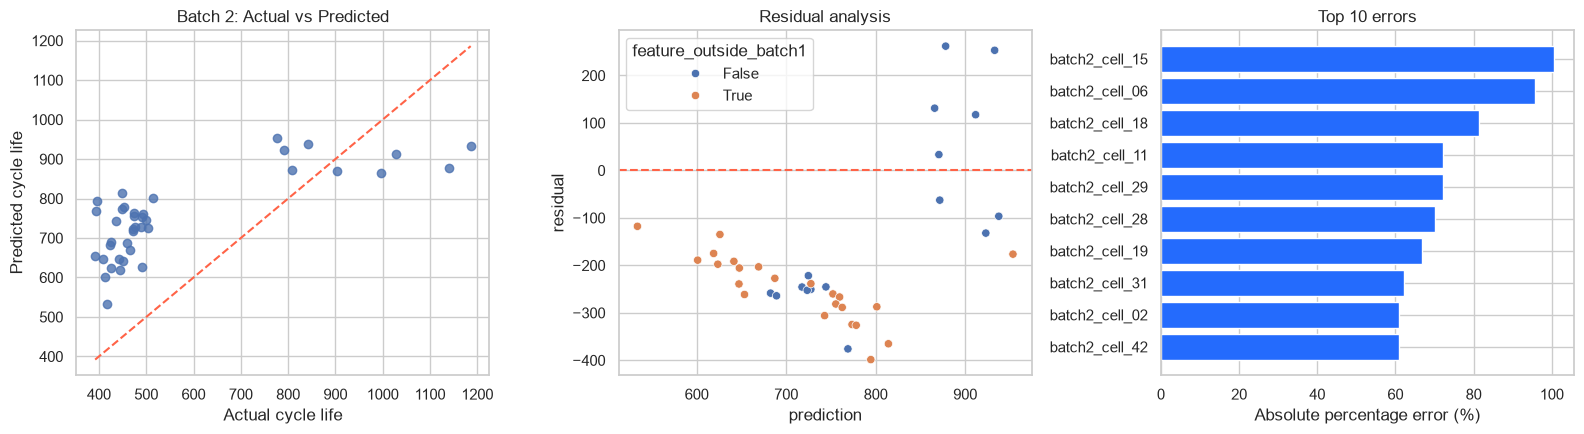

In [7]:
predictions = batch2[['cell_id', GROUP, TARGET] + FEATURES].copy()
predictions['prediction'] = test_pred
predictions['residual'] = predictions[TARGET] - predictions['prediction']
predictions['APE (%)'] = np.abs(predictions['residual']) / predictions[TARGET] * 100
predictions['feature_outside_batch1'] = False
for feature in FEATURES:
    outside = (predictions[feature] < batch1[feature].min()) | (predictions[feature] > batch1[feature].max())
    predictions['feature_outside_batch1'] |= outside

predictions['policy_seen_in_batch1'] = predictions[GROUP].isin(set(batch1[GROUP]))
predictions['structure_group'] = np.where(
    predictions[GROUP].str.contains('newstructure', case=False, na=False),
    'newstructure', 'standard'
)
predictions.to_csv(RESULTS_DIR / 'batch2_predictions.csv', index=False)

subgroup_rows = []
subgroups = {
    '전체': predictions,
    '일반 구조': predictions[predictions['structure_group'] == 'standard'],
    'newstructure': predictions[predictions['structure_group'] == 'newstructure'],
    'Batch 1 범위 내부': predictions[~predictions['feature_outside_batch1']],
    'Batch 1 범위 외부': predictions[predictions['feature_outside_batch1']],
}
for name, subset in subgroups.items():
    subgroup_rows.append({
        'group': name,
        'n': len(subset),
        'MAPE (%)': mean_absolute_percentage_error(subset[TARGET], subset['prediction']) * 100,
        'actual_median': subset[TARGET].median(),
        'prediction_median': subset['prediction'].median(),
    })
subgroup_performance = pd.DataFrame(subgroup_rows)
subgroup_performance.to_csv(RESULTS_DIR / 'batch2_subgroup_performance.csv', index=False)

coef = pd.DataFrame({
    'feature': FEATURES,
    'standardized_coefficient': final_model.named_steps['model'].coef_,
}).sort_values('standardized_coefficient', key=np.abs, ascending=False)
coef.to_csv(RESULTS_DIR / 'ridge_coefficients.csv', index=False)

joblib.dump(final_model, MODEL_DIR / 'ridge_batch1.joblib')
with open(MODEL_DIR / 'model_config.json', 'w', encoding='utf-8') as f:
    json.dump({'features': FEATURES, 'alpha': best_alpha, 'target': TARGET, 'test_batch': 'Batch 2'}, f, ensure_ascii=False, indent=2)

display(predictions.sort_values('APE (%)', ascending=False).head(10))
display(subgroup_performance)
display(coef)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(batch2[TARGET], test_pred, alpha=.8)
lims = [min(batch2[TARGET].min(), test_pred.min()), max(batch2[TARGET].max(), test_pred.max())]
axes[0].plot(lims, lims, '--', color='tomato')
axes[0].set(xlabel='Actual cycle life', ylabel='Predicted cycle life', title='Batch 2: Actual vs Predicted')

sns.scatterplot(data=predictions, x='prediction', y='residual', hue='feature_outside_batch1', ax=axes[1])
axes[1].axhline(0, ls='--', color='tomato')
axes[1].set(title='Residual analysis')

top_errors = predictions.nlargest(10, 'APE (%)').sort_values('APE (%)')
axes[2].barh(top_errors['cell_id'], top_errors['APE (%)'], color='#246BFD')
axes[2].set(xlabel='Absolute percentage error (%)', title='Top 10 errors')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'batch2_error_analysis.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. 해석 기준

- Train-Valid Gap이 크면 Batch 1 내부 과적합 가능성을 확인합니다.
- Valid-Test Gap이 크면 배치 간 분포 차이와 일반화 저하를 확인합니다.
- Target-Test Gap은 원논문 9.1%와의 단순 수치 비교이며, 피처와 검증 설계 차이를 함께 설명해야 합니다.
- Batch 2 오차 상위 셀의 충전 정책과 입력 범위 이탈 여부를 중심으로 원인을 분석합니다.

## 8. README용 성능 및 배치 차이 시각화

성능표만으로 드러나지 않는 Batch 2의 일반화 저하를 설명하기 위해 다음을 시각화합니다.

- Train·Valid·Test MAPE와 원논문 목표
- Batch 1 실제 수명, Batch 2 실제 수명, Batch 2 예측 수명의 분포
- 셀 구조와 Batch 1 입력 범위 이탈 여부에 따른 MAPE


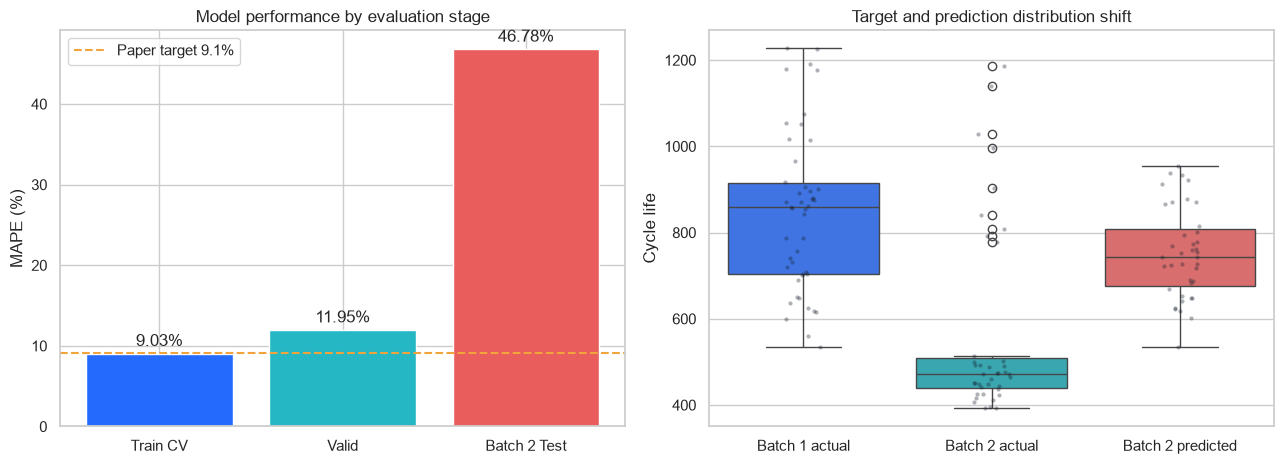

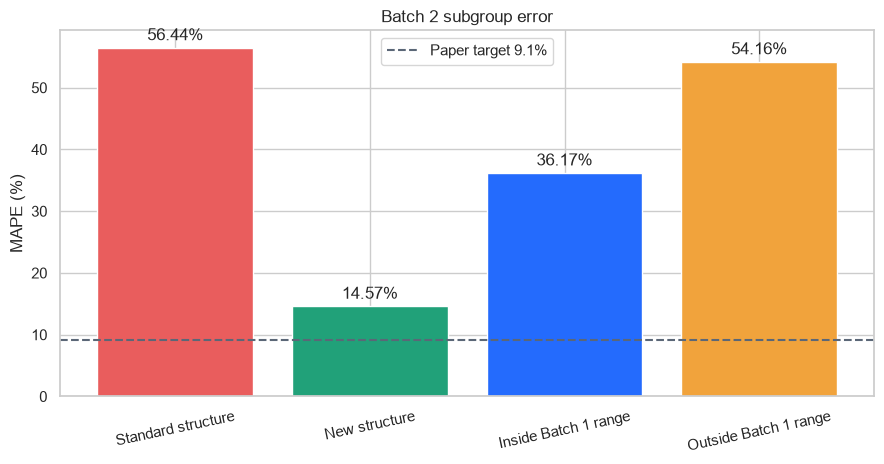

In [8]:
README_IMAGE_DIR = PROJECT_ROOT / 'docs' / 'images'
README_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

score_names = ['Train CV', 'Valid', 'Batch 2 Test']
score_values = [
    train_cv_metrics['MAPE (%)'],
    valid_metrics['MAPE (%)'],
    test_metrics['MAPE (%)'],
]
bars = axes[0].bar(score_names, score_values, color=['#246BFD', '#25B7C4', '#E95D5D'])
axes[0].axhline(PAPER_TARGET_MAPE, color='#F1A33C', linestyle='--', label='Paper target 9.1%')
axes[0].bar_label(bars, fmt='%.2f%%', padding=3)
axes[0].set(ylabel='MAPE (%)', title='Model performance by evaluation stage')
axes[0].legend()

distribution = pd.DataFrame({
    'Batch 1 actual': pd.Series(batch1[TARGET].to_numpy()),
    'Batch 2 actual': pd.Series(batch2[TARGET].to_numpy()),
    'Batch 2 predicted': pd.Series(test_pred),
}).melt(var_name='group', value_name='cycle_life').dropna()
sns.boxplot(data=distribution, x='group', y='cycle_life', hue='group', palette=['#246BFD', '#25B7C4', '#E95D5D'], ax=axes[1])
sns.stripplot(data=distribution, x='group', y='cycle_life', color='#182230', alpha=.35, size=3, ax=axes[1])
axes[1].set(xlabel='', ylabel='Cycle life', title='Target and prediction distribution shift')

plt.tight_layout()
plt.savefig(README_IMAGE_DIR / 'day2_performance_and_shift.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = subgroup_performance[subgroup_performance['group'] != '전체'].copy()
group_labels = {
    '일반 구조': 'Standard structure',
    'newstructure': 'New structure',
    'Batch 1 범위 내부': 'Inside Batch 1 range',
    'Batch 1 범위 외부': 'Outside Batch 1 range',
}
plot_df['group_label'] = plot_df['group'].map(group_labels)
bars = ax.bar(plot_df['group_label'], plot_df['MAPE (%)'], color=['#E95D5D', '#21A179', '#246BFD', '#F1A33C'])
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.axhline(PAPER_TARGET_MAPE, color='#5B6777', linestyle='--', label='Paper target 9.1%')
ax.set(ylabel='MAPE (%)', title='Batch 2 subgroup error')
ax.tick_params(axis='x', rotation=12)
ax.legend()
plt.tight_layout()
plt.savefig(README_IMAGE_DIR / 'day2_subgroup_error.png', dpi=180, bbox_inches='tight')
plt.show()
